# Fast Food Marketing Campaign A/B Test

## Project Overview
This notebook evaluates the results of an A/B test conducted by a fast-food chain to determine which of three marketing promotions generated the strongest sales for a newly introduced menu item. Weekly sales were recorded for four weeks across multiple store locations and market sizes.

## Objective
The goal is to identify which promotion performs best and to determine whether the observed differences in sales are statistically significant.

## Scope
This notebook focuses on:
- loading and validating the dataset
- exploring the structure and quality of the data
- comparing sales across promotions
- testing whether promotion-level sales differences are statistically significant
- providing a final business recommendation

## Analysis Plan

This notebook combines **Exploratory Data Analysis (EDA)** and **Confirmatory Data Analysis (CDA)**:

- **EDA** is used first to inspect the dataset, check for missing values or duplicates, study the distribution of sales, and compare promotion groups visually.
- **CDA** is then used to formally test whether the three promotions produced different average sales outcomes.

### Main Question
Which promotion led to the strongest sales performance?

### Sub-Questions
1. Is the dataset clean and ready for analysis?
2. How are sales distributed overall?
3. How do sales vary by promotion?
4. Are there visible outliers or differences in spread between promotion groups?
5. Are the differences in average sales statistically significant?
6. Which promotion should the company choose based on the results?

### Hypotheses
- **Null hypothesis (H0):** Mean sales are equal across all three promotions.
- **Alternative hypothesis (H1):** At least one promotion has a different mean sales value.

## Setup

This section imports the libraries used throughout the notebook and configures display and plotting settings.
Keeping imports, global options, and the random seed in one place makes the notebook easier to read, reproduce, and modify.

In [30]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(42)

## Load Dataset and Quick Validation

We begin by loading the dataset and validating its structure. This step helps confirm that the file was read correctly and that the variables match the project description before moving into deeper analysis.

In [31]:
dataset_path = Path(kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test"))
csv_path = dataset_path / "WA_Marketing-Campaign.csv"
df = pd.read_csv(csv_path)
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [32]:
df.shape

(548, 7)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


In [34]:
df.describe(include='all')

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548,548.000000,548.000000,548.000000,548.000000,548.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Medium,NaN,NaN,NaN,NaN,NaN
freq,NaN,320,NaN,NaN,NaN,NaN,NaN
mean,5.715328,NaN,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,NaN,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,NaN,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,NaN,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,NaN,708.000000,12.000000,3.000000,3.250000,60.477500


In [35]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

### Initial Validation Findings

The dataset loaded successfully, the columns matched the project description, and the basic structure was suitable for analysis. The checks for missing values and duplicate rows showed no major data quality issues, so the dataset was ready for exploratory and statistical analysis without additional cleaning.

## Exploratory Data Analysis

The next step is to understand the dataset visually. We begin with univariate analysis to inspect distributions and category counts, then move to bivariate analysis to compare sales across promotion groups.

### Distribution of Sales

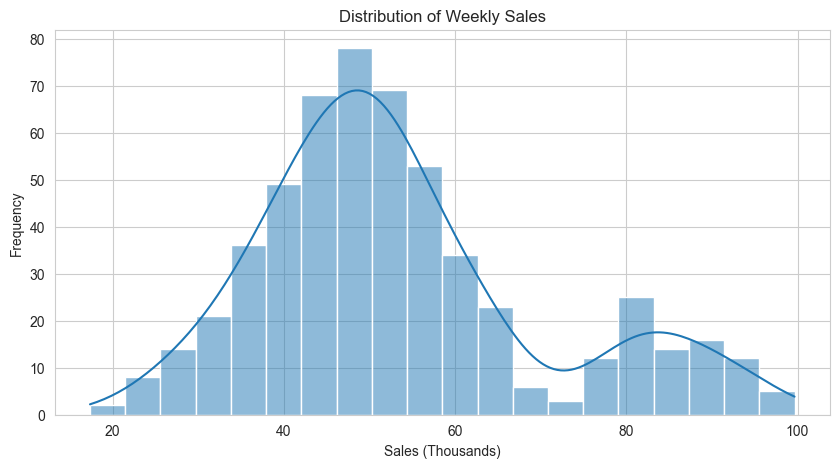

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='SalesInThousands', bins=20, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Sales (Thousands)')
plt.ylabel('Frequency')
plt.show()

The sales distribution appears **unimodal with a slight right skew**. Most observations are concentrated in the middle range, while a smaller number of higher sales values extend the upper tail. This suggests that extremely high weekly sales occurred, but they were not the typical outcome.

### Promotion and Market Composition

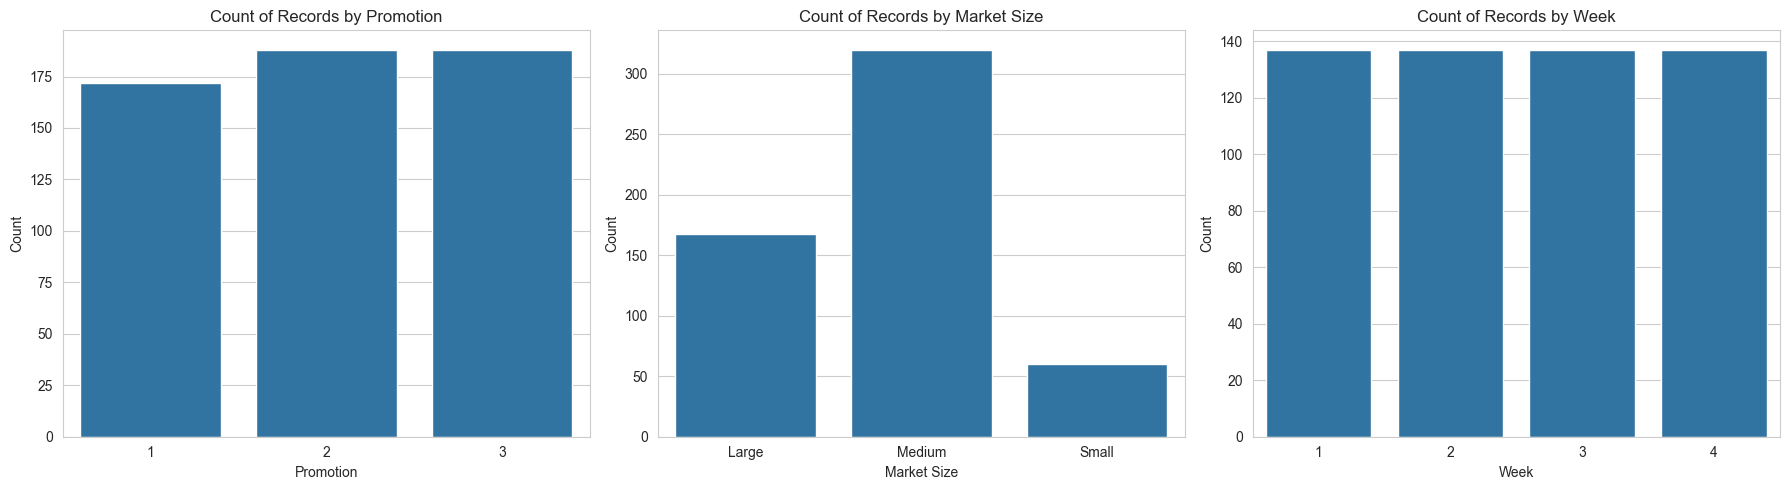

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Promotion', ax=axes[0])
axes[0].set_title('Count of Records by Promotion')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='MarketSize', order=sorted(df['MarketSize'].unique()), ax=axes[1])
axes[1].set_title('Count of Records by Market Size')
axes[1].set_xlabel('Market Size')
axes[1].set_ylabel('Count')

sns.countplot(data=df, x='week', ax=axes[2])
axes[2].set_title('Count of Records by Week')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

The groups were **reasonably balanced overall**, which supports a fair comparison across promotions. Promotion 1 had slightly fewer observations than Promotions 2 and 3, but the difference was not large, and the weekly counts appeared evenly distributed. This strengthens the credibility of the ANOVA results.

### Summary Statistics by Promotion

In [39]:
df['Promotion'] = df['Promotion'].astype(int)
promotion_stats = df.groupby('Promotion')['SalesInThousands'].describe()
promotion_stats

,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
1,172.0,58.099012,16.553782,30.81,46.3525,55.385,63.6175,99.65
2,188.0,47.329415,15.108955,17.34,38.1700,45.385,51.7450,88.64
3,188.0,55.364468,16.766231,22.18,44.1975,51.165,61.7325,96.48


The summary statistics show a clear difference in average sales across the three promotions. **Promotion 1 recorded the highest mean sales (58.10)**, followed by **Promotion 3 (55.36)**, while **Promotion 2 had the lowest mean sales (47.33)**. The spread is fairly similar across groups, which supports a direct comparison of their average performance.

### Mean Sales Ranking

Before interpreting the hypothesis tests, it is useful to compare the average sales directly. This gives the business ranking, while the statistical tests tell us whether the observed differences are likely to be real rather than random.

In [40]:
mean_sales = (
    df.groupby('Promotion', as_index=False)['SalesInThousands']
      .mean()
      .sort_values('SalesInThousands', ascending=False)
)

mean_sales

,Promotion,SalesInThousands
0,1,58.099012
2,3,55.364468
1,2,47.329415


The mean sales ranking confirms the business ordering of the campaigns: **Promotion 1 ranked first**, **Promotion 3 ranked second**, and **Promotion 2 ranked last**. This gives the practical conclusion, which is then tested formally through ANOVA and Tukey's HSD.

### Sales Distribution by Promotion

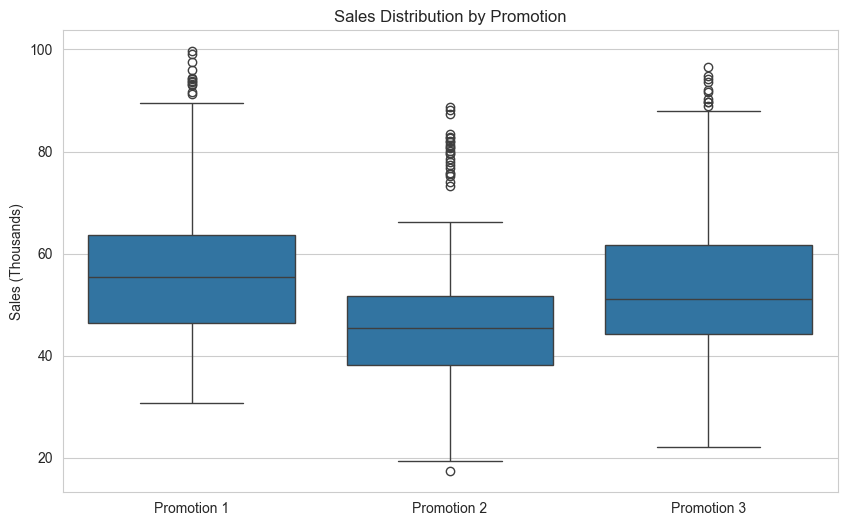

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Promotion', y='SalesInThousands', order=[1, 2, 3])
plt.title('Sales Distribution by Promotion')
plt.xlabel('')
plt.ylabel('Sales (Thousands)')
plt.xticks([0, 1, 2], ['Promotion 1', 'Promotion 2', 'Promotion 3'])
plt.show()

The boxplot shows a clear visual separation between the groups. **Promotion 1 has the highest median sales**, **Promotion 3 is close behind**, and **Promotion 2 has the lowest median**. All three groups show some high-end outliers, but the main pattern is that Promotion 2 sits noticeably below the other two campaigns.

### Sales by Promotion Across Weeks

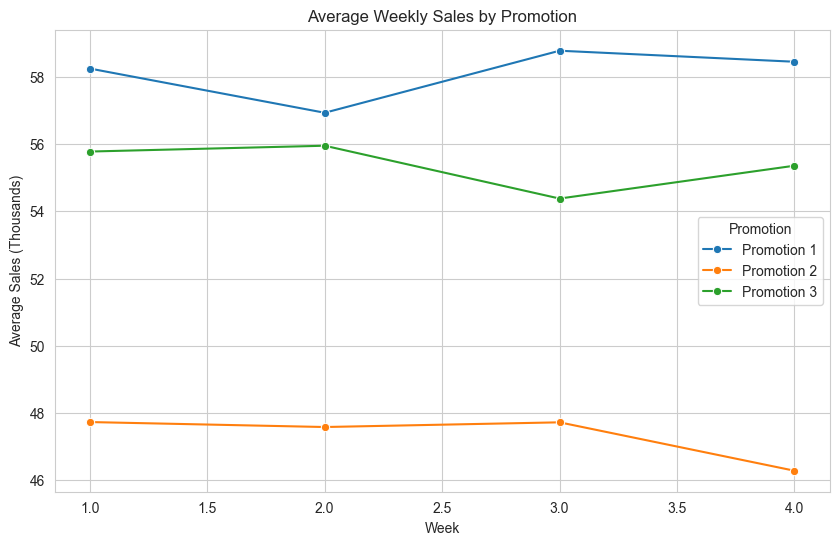

In [42]:
weekly_avg = (
    df.groupby(['week', 'Promotion'], as_index=False)['SalesInThousands']
      .mean()
)
weekly_avg['PromotionLabel'] = weekly_avg['Promotion'].map({
    1: 'Promotion 1',
    2: 'Promotion 2',
    3: 'Promotion 3'
})

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=weekly_avg,
    x='week',
    y='SalesInThousands',
    hue='PromotionLabel',
    hue_order=['Promotion 1', 'Promotion 2', 'Promotion 3'],
    marker='o'
)
plt.title('Average Weekly Sales by Promotion')
plt.xlabel('Week')
plt.ylabel('Average Sales (Thousands)')
plt.legend(title='Promotion')
plt.show()

The weekly trend shows that **Promotion 2 generally stayed below the other campaigns**, while **Promotions 1 and 3 remained the stronger performers over time**. The lines may fluctuate from week to week, but the visual pattern supports the later statistical result that Promotion 2 underperformed relative to the top two options.

## Confirmatory Analysis: ANOVA

To determine whether the observed differences in average sales are statistically significant, we use a one-way ANOVA. This test compares the mean sales of the three promotion groups.

Decision rule:
- If the p-value is less than 0.05, we reject the null hypothesis.
- If the p-value is greater than or equal to 0.05, we fail to reject the null hypothesis.

In [43]:
group_1_sales = df[df['Promotion'] == 1]['SalesInThousands']
group_2_sales = df[df['Promotion'] == 2]['SalesInThousands']
group_3_sales = df[df['Promotion'] == 3]['SalesInThousands']

anova_result = f_oneway(group_1_sales, group_2_sales, group_3_sales)
anova_result

F_onewayResult(statistic=np.float64(21.953485793080677), pvalue=np.float64(6.765849261408762e-10))

### ANOVA Interpretation

The ANOVA result was statistically significant (**F = 21.95, p < 0.001**), so the null hypothesis was rejected. This means the average sales were **not equal across the three promotions**, and at least one campaign performed differently from the others.

## Post-Hoc Analysis: Tukey's HSD

Since ANOVA only tells us that at least one group differs, we now apply Tukey's HSD test to compare each pair of promotions directly.

In [44]:
tukey_data = df[['Promotion', 'SalesInThousands']].copy()
tukey = pairwise_tukeyhsd(endog=tukey_data['SalesInThousands'], groups=tukey_data['Promotion'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


### Tukey Test Interpretation

Tukey's HSD clarified the direction and size of the differences:

- **Promotion 1 outperformed Promotion 2 by about 10.77 thousand in mean sales**, and this difference was statistically significant.
- **Promotion 3 outperformed Promotion 2 by about 8.04 thousand in mean sales**, and this difference was also statistically significant.
- **Promotion 1 exceeded Promotion 3 by about 2.73 thousand**, but that difference was **not statistically significant**.

This means **Promotion 2 was the weakest option**, while **Promotions 1 and 3 were the two strongest campaigns**. Since Promotion 1 had the highest average sales overall, it remains the best final recommendation.

## Mean Sales Comparison

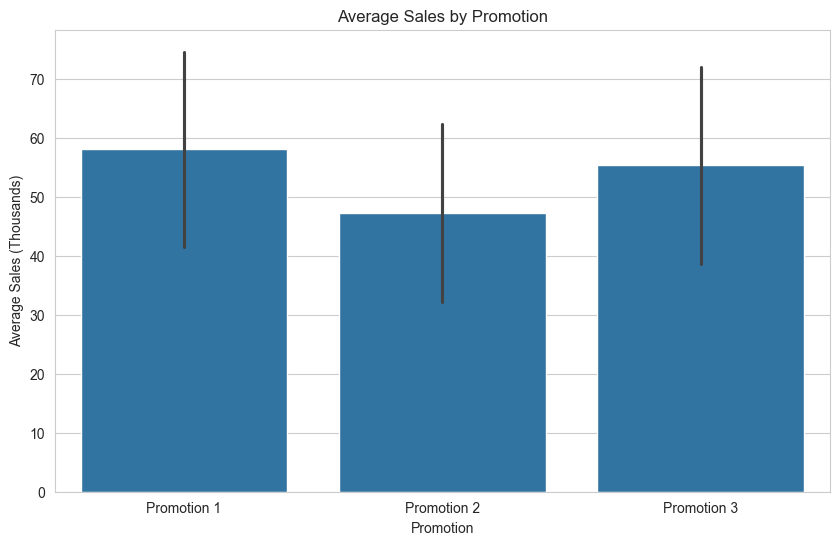

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Promotion', y='SalesInThousands', errorbar='sd', order=[1, 2, 3])
plt.title('Average Sales by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Average Sales (Thousands)')
plt.xticks([0, 1, 2], ['Promotion 1', 'Promotion 2', 'Promotion 3'])
plt.show()

The barplot confirms the final ranking from the earlier analysis: **Promotion 1 had the highest average sales**, **Promotion 3 ranked second**, and **Promotion 2 ranked last**. The gap between Promotion 2 and the other two campaigns is visually clear, which matches the Tukey test results.

## Summary and Next Steps

### Key Findings
- The dataset was loaded and validated before analysis.
- Descriptive statistics showed that **Promotion 1 had the highest average sales**, followed by **Promotion 3**, while **Promotion 2 had the lowest**.
- ANOVA tested whether the three promotions had equal mean sales and indicated that at least one promotion differed significantly.
- Tukey's HSD showed that **Promotion 1 significantly outperformed Promotion 2**, and **Promotion 3 also significantly outperformed Promotion 2**.
- There was **no statistically significant difference between Promotion 1 and Promotion 3**.

### Recommendation
Based on both the descriptive statistics and the post-hoc test, **Promotion 1 is the strongest overall choice** because it achieved the highest average sales. Promotion 3 is also competitive, but it did not significantly outperform Promotion 1. Promotion 2 should not be prioritized because it delivered the weakest performance.

### Next Steps
Future analysis could examine:
- whether promotion performance changes by **market size**
- whether certain promotions perform better in specific **weeks**
- whether **store age** influences campaign results
- whether the top-performing promotion is also the most **consistent** across locations